## 3. Learning Causal Discovery, Which Identifies the Structure of a Causal Graph from Data

### 3.1. What Is Causal Discovery?

![03](../image/03-000-KR.excalidraw.png)

- Constraint-based: `PC`, `FCI`
- Score-based: `GES`, `FGES`

### 3.2. Dataset Description

- [Social Class, Parental Encouragement, and Educational Aspirations](https://www.jstor.org/stable/2775558?origin=JSTOR-pdf)

The study covered 10,318 high school seniors in Wisconsin, United States, in 1957. The data were obtained by randomly sampling approximately one-third of all graduating students at the time.

```py
sex = { # Sex
    "1": male,
    "2": female,
}
iq = { # Intelligence
    "1": "Low",
    "2": "Lower middle",
    "3": "Upper middle",
    "4": "High",
}
cp = { # College plans
    "1": "Yes",
    "2": "No,
}
pe = { # Parental encouragement (modified from the original data)
    "1": "High",
    "2": "Low",
}
iq = {
    "1": "Low",
    "2": "Lower middle",
    "3": "Upper middle",
    "4": "High",
}
```

![03](../image/03-002.excalidraw.png)


![03](../image/03-003.excalidraw.png)

![03](../image/03-001.excalidraw.png)


- SES and IQ had a strong influence on CP for both men and women.
- PE was the variable with the greatest influence on CP.
- Women were influenced by PE more strongly than men were.
- Men were influenced by SES and IQ to the same degree, whereas women were influenced more strongly by SES than by IQ.

In [2]:
import pandas as pd
import numpy as np


In [3]:
from pgmpy.datasets import load_dataset

dataset = load_dataset("college_plans")
data = dataset.data
data.head()


,sex,iq,cp,pe,ses
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,1,1
3,1,1,1,1,1
4,1,1,1,1,2


In [4]:
from pgmpy_tutorial.helper_functions import load_college_plans

data = load_college_plans()
data.head()


,sex,iq,cp,pe,ses
0,1,1,2,1,1
1,1,1,2,1,1
2,1,1,2,1,1
3,1,1,2,1,1
4,1,1,2,1,2


In [5]:
data.corr()


,sex,iq,cp,pe,ses
sex,1.000000,-0.013200,-0.085137,-0.122912,-0.016583
iq,-0.013200,1.000000,0.378948,0.324478,0.276442
cp,-0.085137,0.378948,1.000000,0.542627,0.393085
pe,-0.122912,0.324478,0.542627,1.000000,0.427593
ses,-0.016583,0.276442,0.393085,0.427593,1.000000


### 3.3. Explanation of the PC Algorithm

![03](../image/03-004-KR.excalidraw.png)

![03](../image/03-005.excalidraw.png)

In [6]:
from pgmpy.causal_discovery import PC

pc = PC(variant="parallel", ci_test="chi_square", significance_level=0.01, return_type="pdag")
pc.fit(data)


Working for n conditional variables: 5: 100%|██████████| 5/5 [00:00<00:00, 43.74it/s]


,variant,'parallel'
,ci_test,'chi_square'
,return_type,'pdag'
,significance_level,0.01
,max_cond_vars,5
,orient_rule,None
,expert_knowledge,None
,n_jobs,-1
,show_progress,True


In [47]:
pdag = pc.causal_graph_


<Axes: >

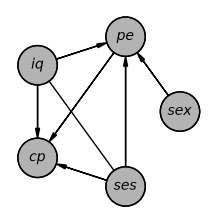

In [46]:
pgm = pdag.to_daft(node_pos="circular")

pgm.render()


In [17]:
pdag


In [7]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(data, train_size=0.8, shuffle=True, random_state=42)


In [10]:
pc = PC(variant="parallel", ci_test="chi_square", significance_level=0.01, return_type="dag")
pc.fit(data_train)

print(pc.score(X=data_test, metric="correlation_score"))


  0%|          | 0/5 [00:00<?, ?it/s]

Working for n conditional variables: 5: 100%|██████████| 5/5 [00:00<00:00, 53.96it/s]

1.0
